In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os

import sys
sys.path.append('..') 

from src.kitti_utils import (parse_timestamps, get_frame_interval, 
                             load_oxts_velocity, load_velodyne_points, 
                             project_velo_to_image, load_kitti_calib)
from src.optical_flow import compute_sparse_flow
from src.geometry import calculate_tti_from_points, estimate_dynamic_foe

# Paths to dataset
BASE_PATH = "D:/reyci/Politecnico di Milano/2025-2/Image Analysis and CV/Project/Code/IACV-Depth-Estimation-from-Temporal-Stereo-in-Monocular-Driving-Sequences-/data/raw/2011_09_26_drive_0001_extract"
IMG_PATH = os.path.join(BASE_PATH, "image_02/data")
OXTS_PATH = os.path.join(BASE_PATH, "oxts/data")
TIME_PATH = os.path.join(BASE_PATH, "image_02/timestamps.txt")
CALIB_CAM_PATH = os.path.join(BASE_PATH, "calib/calib_cam_to_cam.txt")
CALIB_VELO_PATH = os.path.join(BASE_PATH, "calib/calib_velo_to_cam.txt")

In [2]:
# Define the frames to compare
idx_t = 5
idx_t1 = 8

# Load images
img_t = cv2.imread(os.path.join(IMG_PATH, f"{idx_t:010d}.png"))
img_t1 = cv2.imread(os.path.join(IMG_PATH, f"{idx_t1:010d}.png"))

# Load metadata
timestamps = parse_timestamps(TIME_PATH)
dt = get_frame_interval(timestamps, idx_t)
vf = load_oxts_velocity(OXTS_PATH, idx_t)

print(f"Delta t: {dt:.4f} s | Forward velocity vf: {vf:.2f} m/s")

Delta t: 0.1031 s | Forward velocity vf: 13.30 m/s


In [3]:
# --- Celda 3: Procesamiento de Geometría y Profundidad ---

# 1. Cargar calibración real (Necesario para obtener el FOE teórico)
# load_kitti_calib lee los archivos .txt que encontraste en la carpeta del dataset
P_rect, Tr_velo_to_cam = load_kitti_calib(CALIB_CAM_PATH, CALIB_VELO_PATH )

# 2. Definir el FOE (Foco de Expansión)
# Según la teoría de Caglioti, el FOE teórico coincide con el centro óptico (cx, cy)
# Extraemos cx y cy de la matriz P_rect (columna 2, filas 0 y 1)
foe = np.array([P_rect[0, 2], P_rect[1, 2]])

# 3. Computar flujo óptico esparzo (Lucas-Kanade)
p0, p1 = compute_sparse_flow(img_t, img_t1)

# 4. Filtrar ruido en el flujo óptico
# Calculamos la magnitud del movimiento de cada punto
flow_dist = np.linalg.norm(p1 - p0, axis=1)

# Solo conservamos puntos que se hayan movido más de 0.5 píxeles 
# Puntos estáticos o con ruido de subpíxel generan TTIs infinitos
mask_flow = flow_dist > 0.05

# 5. Calcular TTI (Time-to-Contact) en segundos
# Usamos solo los puntos que superaron el filtro de movimiento
ttis = calculate_tti_from_points(p0[mask_flow], p1[mask_flow], foe, dt)
p0_valid = p0[mask_flow] 

# 6. Estimar profundidad (Z = vf * tau)
depths_estimated = vf * ttis

# 7. Filtro de Rango Cinemático (Outlier Removal)
# Descartamos profundidades físicamente imposibles para este escenario (2m a 80m)
# Esto limpia los errores de escala masivos que vimos anteriormente
valid_z_mask = (depths_estimated > 2) & (depths_estimated < 80)

# 8. Definir variables finales para la validación con LiDAR (Celda 5)
final_p0 = p0_valid[valid_z_mask]
final_depths = depths_estimated[valid_z_mask]

# --- Reporte de estado ---
print(f"FOE Teórico (Centro Óptico): {foe}")
print(f"Puntos detectados inicialmente: {len(p0)}")
print(f"Puntos válidos tras filtrado de flujo y profundidad: {len(final_p0)}")

FOE Teórico (Centro Óptico): [609.5593 172.854 ]
Puntos detectados inicialmente: 46
Puntos válidos tras filtrado de flujo y profundidad: 11


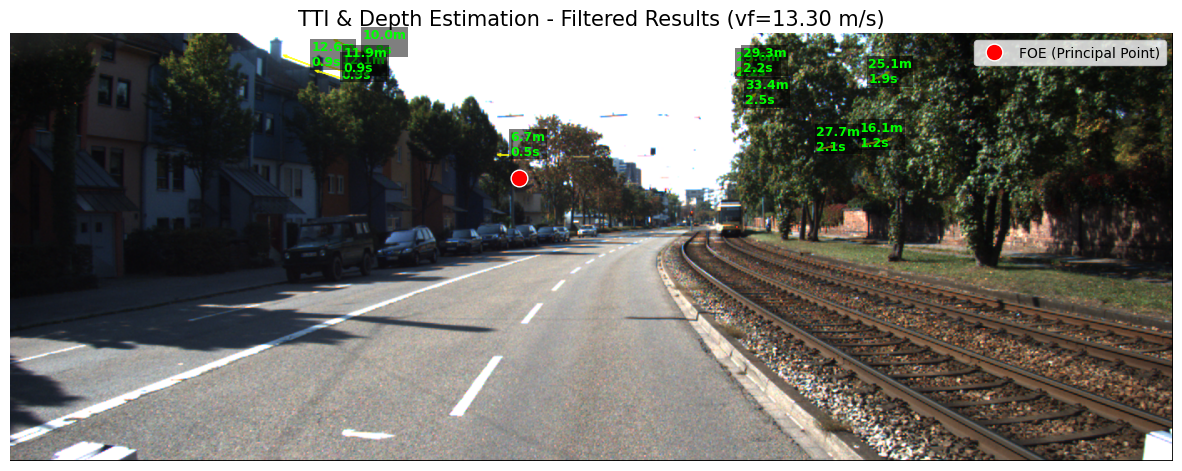

In [4]:
# --- Celda 4: Visualización de resultados sobre la imagen ---

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB))

# Graficamos solo los puntos que pasaron todos los filtros (final_p0)
# Para dibujar las flechas de flujo, necesitamos recuperar el p1 correspondiente
# Así que usamos la máscara lógica de la celda anterior
p1_valid = p1[mask_flow][valid_z_mask]

for i in range(len(final_p0)):
    a, b = final_p0[i].ravel()
    c, d = p1_valid[i].ravel()

    # 1. Dibujar el vector de movimiento (flecha amarilla)
    plt.arrow(a, b, c - a, d - b, color='yellow', head_width=3, alpha=0.8)

    # 2. Mostrar texto de TTI y Profundidad (etiquetas verdes)
    # Solo mostramos si el valor es razonable (ya filtrado, pero por seguridad)
    plt.text(
        a, b,
        f"{final_depths[i]:.1f}m\n{final_depths[i]/vf:.1f}s", # Profundidad y TTI
        color='lime',
        fontsize=9,
        fontweight='bold',
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1) # Fondo negro para legibilidad
    )

# 3. Dibujar el FOE Teórico (el que realmente usamos para el cálculo)
plt.plot(foe[0], foe[1], 'ro', markersize=12, markeredgecolor='white', label='FOE (Principal Point)')

plt.title(f"TTI & Depth Estimation - Filtered Results (vf={vf:.2f} m/s)", fontsize=15)
plt.legend()
plt.axis('off')
plt.show()

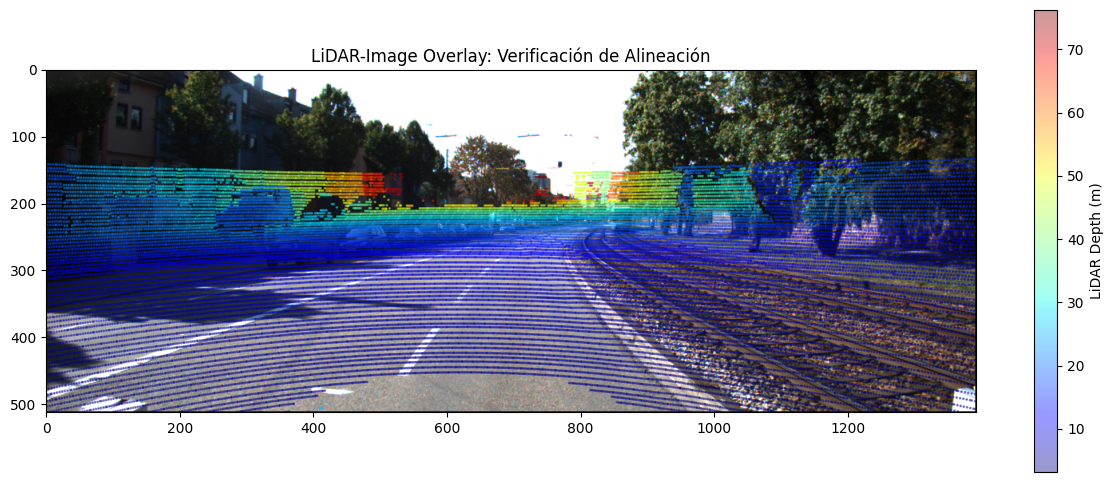

--- ESTADÍSTICAS DE VALIDACIÓN ---
Puntos validados con LiDAR: 2
Mean Relative Error (MRE): 26.80%
Median Error: 26.80%


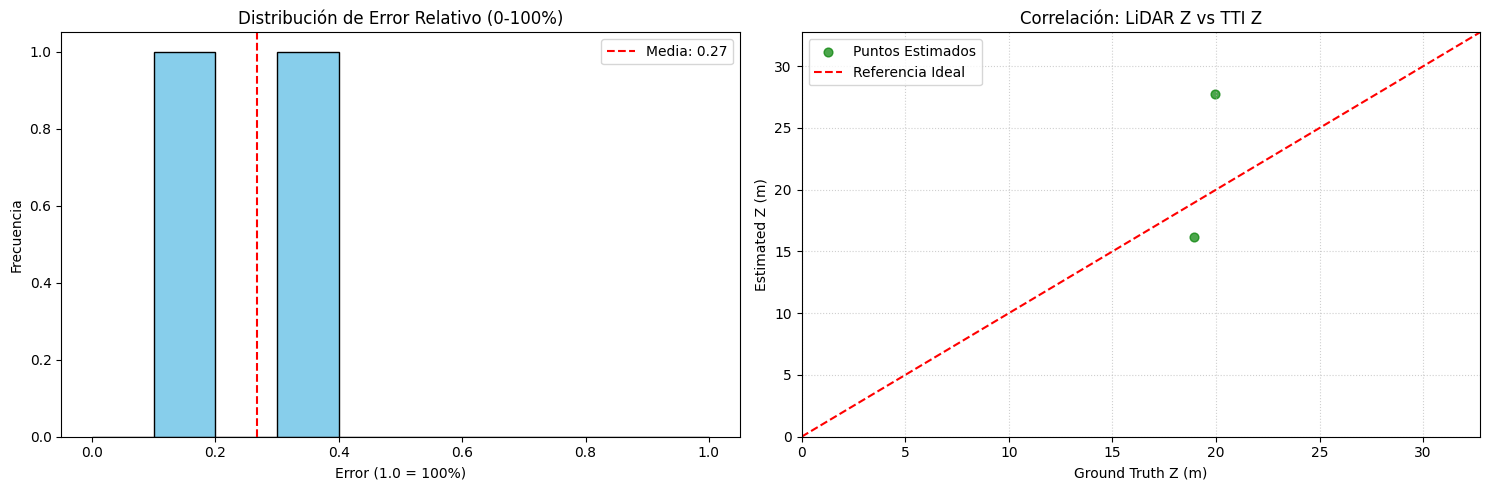

In [5]:
# --- Celda 5: Validación con Ground Truth (LiDAR) ---

# 1. Cargar y Proyectar Ground Truth (LiDAR)
velo_file = os.path.join(BASE_PATH, f"velodyne_points/data/{idx_t:010d}.txt")
pts_3d = load_velodyne_points(velo_file)

# Filtrar: Solo puntos frente al vehículo y a más de 5 metros para evitar ruido del capó
pts_3d = pts_3d[pts_3d[:, 0] > 2]

# Proyectar puntos LiDAR al plano de la imagen usando calibración real
pts_2d, gt_depths = project_velo_to_image(pts_3d, P_rect, Tr_velo_to_cam)

# --- Sub-celda: Validación Visual de Alineación ---
plt.figure(figsize=(15, 6))
h, w = img_t.shape[:2]
plt.imshow(cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB))

# Solo graficamos los puntos LiDAR que caen dentro del área de la imagen
in_image = (pts_2d[:, 0] >= 0) & (pts_2d[:, 0] < w) & \
           (pts_2d[:, 1] >= 0) & (pts_2d[:, 1] < h)

plt.scatter(
    pts_2d[in_image, 0], 
    pts_2d[in_image, 1], 
    c=gt_depths[in_image], 
    s=1, cmap='jet', alpha=0.4
)

plt.xlim(0, w)
plt.ylim(h, 0) # Invertir eje Y para que coincida con coordenadas de imagen
plt.colorbar(label='LiDAR Depth (m)')
plt.title("LiDAR-Image Overlay: Verificación de Alineación")
plt.show()

# 2. Matching Espacial (cKDTree)
# Asociamos nuestros 9 puntos estimados con la nube de puntos del LiDAR
tree = cKDTree(pts_2d)
errors = []
z_comparison = []

# Iteramos sobre los puntos filtrados en la Celda 3 (final_p0)
for i, pt_est in enumerate(final_p0):
    # Buscamos el punto LiDAR más cercano en un radio de 5 píxeles
    dist_px, idx_lidar = tree.query(pt_est, distance_upper_bound=30)

    if dist_px < 30:
        z_gt = gt_depths[idx_lidar]
        z_est = final_depths[i]

        # Calculamos Error Relativo
        error_rel = abs(z_est - z_gt) / z_gt
        errors.append(error_rel)
        z_comparison.append((z_gt, z_est))

# 3. Visualización de Estadísticas Finales para el Reporte
if errors:
    print(f"--- ESTADÍSTICAS DE VALIDACIÓN ---")
    print(f"Puntos validados con LiDAR: {len(errors)}")
    print(f"Mean Relative Error (MRE): {np.mean(errors)*100:.2f}%")
    print(f"Median Error: {np.median(errors)*100:.2f}%")

    plt.figure(figsize=(15, 5))

    # Histograma de Errores (Zoom en rango 0-100% para claridad)
    plt.subplot(1, 2, 1)
    plt.hist(errors, bins=10, color='skyblue', edgecolor='black', range=(0, 1))
    plt.axvline(np.mean(errors), color='red', linestyle='--', label=f'Media: {np.mean(errors):.2f}')
    plt.title("Distribución de Error Relativo (0-100%)")
    plt.xlabel("Error (1.0 = 100%)")
    plt.ylabel("Frecuencia")
    plt.legend()

    # Gráfico de Correlación Z-Real vs Z-Estimado
    plt.subplot(1, 2, 2)
    gt_v, est_v = zip(*z_comparison)
    plt.scatter(gt_v, est_v, color='green', s=40, alpha=0.7, label='Puntos Estimados')
    
    # Línea de referencia ideal (Error = 0)
    limit = max(max(gt_v), max(est_v)) + 5
    plt.plot([0, limit], [0, limit], 'r--', label="Referencia Ideal")
    
    plt.xlim(0, limit); plt.ylim(0, limit)
    plt.title("Correlación: LiDAR Z vs TTI Z")
    plt.xlabel("Ground Truth Z (m)")
    plt.ylabel("Estimated Z (m)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Error: No se encontraron coincidencias. Prueba aumentar el radio de búsqueda (distance_upper_bound).")